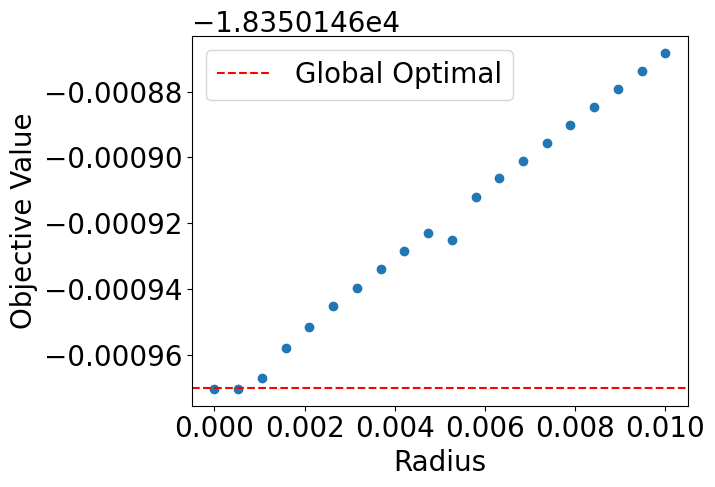

In [1]:
from NSPLIB.src.instances.crude_selection.crude_selection import const_model
from src.models.cz_model import CaoZavalaModel, CaoZavalaAlgo
import cProfile
import numpy as np
radius=np.linspace(0,0.01,20)
objs=[]
for r in radius:
    sto_m = const_model()
    m = CaoZavalaModel.from_sto_m(sto_m)
    m.build()
    binary_ys = [f'pickCrude[{i}]' for i in range(1, 10 + 1)]
    binary_y_val = {y: 0 for y in binary_ys}
    binary_y_val['pickCrude[2]'] = 1
    binary_y_val['pickCrude[3]'] = 1
    binary_y_val['pickCrude[4]'] = 1
    binary_y_val['pickCrude[8]'] = 1
    binary_y_val['pickCrude[10]'] = 1
    m.fix_binary_y(binary_y_val)
    updated_y_bound=m.y_bound
    updated_y_bound['crudeQuantity[1]']=(0,0)
    updated_y_bound['crudeQuantity[5]']=(0,0)
    updated_y_bound['crudeQuantity[6]']=(0,0)
    updated_y_bound['crudeQuantity[7]']=(0,0)
    updated_y_bound['crudeQuantity[9]']=(0,0)
    updated_y_bound['crudeQuantity[2]']=(150,151)
    updated_y_bound['crudeQuantity[3]']=(201,202)
    updated_y_bound['crudeQuantity[4]']=(56,57)
    updated_y_bound['crudeQuantity[8]']=(162,163)
    updated_y_bound['crudeQuantity[10]']=(18,19)
    m.update_y_bound(updated_y_bound)
    crude_obj = -18350.146970266756
    # m.update_y_bound({'crudeQuantity[1]': [0, 0], 'crudeQuantity[2]': [150.75121227052588, 151.000700564433], 'crudeQuantity[3]': [201.1709633227583, 201.29570747217807], 'crudeQuantity[4]': [56.05981734762004, 56.309305641527146], 'crudeQuantity[5]': [0, 0], 'crudeQuantity[6]': [0, 0], 'crudeQuantity[7]': [0, 0], 'crudeQuantity[8]': [162.12190591201795, 162.37139420592507], 'crudeQuantity[9]': [0, 0], 'crudeQuantity[10]': [18.72337265309496, 18.972860947002065]})
    # alg=CaoZavalaAlgo(m,solver="baron")
    # alg.solve(max_iter=1e5, max_time=3600*24, tol=1e-3,ubd_local_solve=1,ubd_midpt_fix=0,ubd_provided=-18350.146929613762)
    from pyomo.environ import Constraint
    def total_y_equals_100_rule(model):
        crude_sol = {}
        crude_sol['crudeQuantity[2]'] = 150.87595641747944
        crude_sol['crudeQuantity[3]'] = 201.29570746971186
        crude_sol['crudeQuantity[4]'] = 56.18456149457359
        crude_sol['crudeQuantity[8]'] = 162.2466500589715
        crude_sol['crudeQuantity[10]'] = 18.848116800048512
        return sum((model.y[i]-crude_sol[i])**2 for i in crude_sol) >= r*r

    m.origin_model.total_y_equals_100 = Constraint(rule=total_y_equals_100_rule)
    from pyomo.opt import SolverFactory
    solver = SolverFactory('baron')
    solver.options['EpsA'] = 0.00000001
    results=solver.solve(m.origin_model)
    objs.append(results["Problem"][0]["Upper bound"])
import matplotlib.pyplot as plt
plt.scatter(radius, objs)
plt.xlabel('Radius', fontsize=20)
plt.ylabel('Objective Value', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().yaxis.offsetText.set_fontsize(20)
plt.axhline(y=-18350.146970266756, color='red', linestyle='--', label='Global Optimal')
plt.legend(fontsize=20)
plt.savefig("graphing/radius_test/Radius_crude_selection.eps", format="eps", dpi=1200, bbox_inches="tight")

In [2]:
sto_m = const_model()
m = CaoZavalaModel.from_sto_m(sto_m)
m.build()
binary_ys = [f'pickCrude[{i}]' for i in range(1, 10 + 1)]
binary_y_val = {y: 0 for y in binary_ys}
binary_y_val['pickCrude[2]'] = 1
binary_y_val['pickCrude[3]'] = 1
binary_y_val['pickCrude[4]'] = 1
binary_y_val['pickCrude[8]'] = 1
binary_y_val['pickCrude[10]'] = 1
m.fix_binary_y(binary_y_val)
from pyomo.opt import SolverFactory
solver = SolverFactory('baron')
solver.options['EpsA'] = 0.0000000001
solver.solve(m.origin_model)


{'Problem': [{'Name': 'problem', 'Lower bound': -18350.146970266756, 'Upper bound': -18350.146970266756, 'Number of objectives': 1, 'Number of constraints': 577, 'Number of variables': 621, 'Sense': 'unknown', 'Missing bounds': '0', 'Iterations': '69', 'Node opt': '-1', 'Node memmax': '6', 'Cpu time': 18.95, 'Wall time': 19.16}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Root node time': 2.02, 'Error rc': 0, 'Time': 19.487483978271484}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}